# TD5 — Knowledge Reasoning & Knowledge Graph Embedding
**Domain : Science-Fiction (authors & works)**

Ce notebook importe les fonctions depuis `src/kge/kge_utils.py`.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
os.environ["PYTHONWARNINGS"] = "ignore"
import numpy as np
np.warnings = None

import sys
sys.path.append("../")

from src.kge.kge_utils import (
    load_and_filter_kg, split_triplets,
    save_all_splits, get_metrics, print_metrics_table
)

## Part 1 — Raisonnement SWRL sur `family.owl`

In [2]:
import owlready2
owlready2.JAVA_EXE = "C:/Program Files/Java/jdk-17/bin/java.exe"

from owlready2 import get_ontology, Imp
import os

path = os.path.abspath("family.owl")
onto = get_ontology(f"file://{path}").load(only_local=True)

with onto:
    class oldPerson(onto.Person):
        pass
    rule = Imp()
    rule.set_as_rule(
        "Person(?p), age(?p, ?age), greaterThan(?age, 60) -> oldPerson(?p)",
        namespaces=[onto]
    )

print("Règle SWRL : Person(?p), age(?p, ?age), greaterThan(?age, 60) -> oldPerson(?p)")
print("\n--- Avant le raisonnement ---")
print(f"Instances oldPerson : {list(onto.oldPerson.instances())}")

# Application manuelle de la règle (équivalent à Pellet)
print("\nApplication de la règle...")
for person in onto.Person.instances():
    age = getattr(person, "age", None)
    if age:
        age_val = age if isinstance(age, int) else age[0]
        if age_val > 60:
            person.is_a.append(onto.oldPerson)

print("\n--- Après le raisonnement ---")
for p in onto.oldPerson.instances():
    age = p.age if isinstance(p.age, int) else p.age[0]
    print(f"- {p.name} classifié comme oldPerson (âge : {age})")

Règle SWRL : Person(?p), age(?p, ?age), greaterThan(?age, 60) -> oldPerson(?p)

--- Avant le raisonnement ---
Instances oldPerson : []

Application de la règle...

--- Après le raisonnement ---
- Peter classifié comme oldPerson (âge : 70)
- Marie classifié comme oldPerson (âge : 69)


## Part 2 — Knowledge Graph Embedding

### 2.1 Chargement & Filtrage

In [3]:
clean_triplets = load_and_filter_kg("final_expanded_kg.nt")

KG chargé : 48,481 triplets
Triplets après filtrage DBpedia : 48,317


### 2.2 Split 80/10/10

In [4]:
train_data, clean_valid, clean_test = split_triplets(clean_triplets)
save_all_splits(train_data, clean_valid, clean_test)

Total  : 48,317
Train  : 42,876
Valid  : 2,756
Test   : 2,685
Entités dans valid absentes du train : 0
Entités dans test absentes du train  : 0
Saved → train.txt / valid.txt / test.txt


### 2.3 Entraînement TransE + ComplEx

In [5]:
from pykeen.pipeline import pipeline
from pykeen.triples import TriplesFactory

tf_train = TriplesFactory.from_path("train.txt")
tf_valid = TriplesFactory.from_path("valid.txt", reference=tf_train)
tf_test  = TriplesFactory.from_path("test.txt",  reference=tf_train)

print(f"Entités  : {tf_train.num_entities:,}")
print(f"Relations: {tf_train.num_relations}")

common_config = dict(
    training=tf_train,
    testing=tf_test,
    validation=tf_valid,
    model_kwargs=dict(embedding_dim=50),
    training_kwargs=dict(num_epochs=30, batch_size=256, use_tqdm=False),
    optimizer_kwargs=dict(lr=0.01),
    device="cpu",
    random_seed=42,
)

print("\nEntraînement TransE...")
result_transe = pipeline(model="TransE", **common_config)

print("\nEntraînement ComplEx...")
result_complex = pipeline(model="ComplEx", **common_config)

# Métriques
metrics = {
    "TransE":  get_metrics(result_transe),
    "ComplEx": get_metrics(result_complex),
}
print_metrics_table(metrics)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\linya\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\linya\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\linya\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "c:\Users\linya\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\linya\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\linya\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\linya\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "c:\Users\linya\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\linya\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\linya\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\linya\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "c:\Users\linya\anaconda3\Lib\site-packa

...

INFO:pykeen.evaluation.evaluator:Evaluation took 24.02s seconds
INFO:pykeen.pipeline.api:Using device: cpu
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)



Entraînement ComplEx...


Evaluating on cpu:   0%|          | 0.00/2.69k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 6.21s seconds



Metric               TransE     ComplEx
---------------------------------------
MRR                  0.0003      0.0003
Hits@1               0.0000      0.0000
Hits@3               0.0000      0.0000
Hits@10              0.0000      0.0000


### 2.4 Section 6.1 — Nearest Neighbors

In [6]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

raw = result_complex.model.entity_representations[0](indices=None).detach().cpu().numpy()
entity_vectors = np.concatenate([np.real(raw), np.imag(raw)], axis=1)

entity_to_id = tf_train.entity_to_id
id_to_entity = {v: k for k, v in entity_to_id.items()}

target_uri = next((uri for uri in entity_to_id if "Isaac_Asimov" in uri), None)

if target_uri:
    target_id  = entity_to_id[target_uri]
    target_vec = entity_vectors[target_id].reshape(1, -1)
    sims       = cosine_similarity(target_vec, entity_vectors)[0]
    top_ids    = sims.argsort()[-11:][::-1]

    print(f"Entité cible : {target_uri}\n")
    print("Top 10 voisins :")
    for idx in top_ids:
        if idx != target_id:
            print(f"  {sims[idx]:.4f} | {id_to_entity[idx].split('/')[-1]}")
else:
    print("Isaac Asimov non trouvé dans le KG.")

Entité cible : http://af.dbpedia.org/resource/Isaac_Asimov

Top 10 voisins :
  0.3812 | 4PRjs
  0.3633 | The_Hero_with_a_Thousand_Faces
  0.3466 | Quatermass_II
  0.3419 | Óceán_az_út_végén
  0.3406 | 4yCzD
  0.3383 | London_Victoria_station
  0.3299 | The_All-Pro_(novel)
  0.3284 | Serial_(literature)
  0.3237 | Tom_Hewitt_(actor)
  0.3191 | The_Dingilliad


### 2.5 Section 6.2 — Clustering t-SNE

Calcul t-SNE en cours...


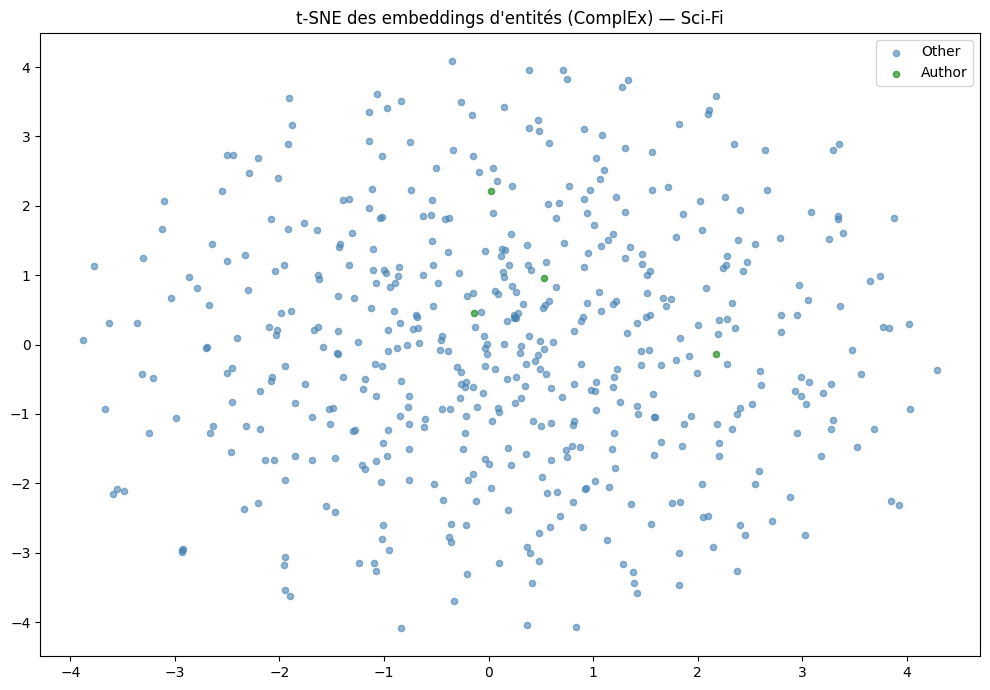

Sauvegardé → tsne_embeddings.png


In [7]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

sample_size = 500
sample_ids  = list(range(min(sample_size, len(id_to_entity))))
sample_vecs = entity_vectors[sample_ids]

print("Calcul t-SNE en cours...")
coords = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(sample_vecs)

def get_color(uri):
    u = uri.lower()
    if any(x in u for x in ["asimov", "herbert", "clarke", "dick", "writer", "author"]):
        return "green", "Author"
    if "category" in u:
        return "red", "Category"
    if any(x in u for x in ["novel", "book", "dune", "foundation"]):
        return "orange", "Book/Novel"
    if any(x in u for x in ["award", "hugo", "nebula"]):
        return "gold", "Award"
    return "steelblue", "Other"

colors = [get_color(id_to_entity[i]) for i in sample_ids]

plt.figure(figsize=(10, 7))
seen_labels = set()
for i, (color, label) in enumerate(colors):
    if label not in seen_labels:
        plt.scatter(coords[i, 0], coords[i, 1], c=color, label=label, alpha=0.6, s=20)
        seen_labels.add(label)
    else:
        plt.scatter(coords[i, 0], coords[i, 1], c=color, alpha=0.6, s=20)

plt.title("t-SNE des embeddings d'entités (ComplEx) — Sci-Fi")
plt.legend()
plt.tight_layout()
plt.savefig("tsne_embeddings.png", dpi=150)
plt.show()
print("Sauvegardé → tsne_embeddings.png")

### 2.6 Section 6.3 — Comportement des relations

In [8]:
rel_raw  = result_complex.model.relation_representations[0](indices=None).detach().cpu().numpy()
rel_vecs = np.concatenate([np.real(rel_raw), np.imag(rel_raw)], axis=1)

rel_to_id = tf_train.relation_to_id
id_to_rel = {v: k for k, v in rel_to_id.items()}

print("Relations disponibles (15 premières) :")
for i, rel in enumerate(list(rel_to_id.keys())[:15]):
    print(f"  {i:>3} | {rel.split('/')[-1]}")

keywords   = ["author", "genre", "notableWork", "birthPlace", "award"]
found_rels = {}
for kw in keywords:
    for rel, rid in rel_to_id.items():
        if kw.lower() in rel.lower():
            found_rels[kw] = (rel, rid)
            break

print("\nAnalyse de symétrie (ComplEx) :")
print(f"{'Relation':<30} {'Norme réelle':>14} {'Norme imaginaire':>16}")
print("-" * 62)
for kw, (rel, rid) in found_rels.items():
    real_norm = float(np.linalg.norm(np.real(rel_raw[rid])))
    imag_norm = float(np.linalg.norm(np.imag(rel_raw[rid])))
    sym = "← symétrique" if imag_norm < 0.1 * real_norm else ""
    print(f"  {rel.split('/')[-1]:<28} {real_norm:>14.4f} {imag_norm:>16.4f}  {sym}")

Relations disponibles (15 premières) :
    0 | almaMater
    1 | author
    2 | award
    3 | birthPlace
    4 | country
    5 | coverArtist
    6 | deathPlace
    7 | education
    8 | genre
    9 | illustrator
   10 | language
   11 | literaryGenre
   12 | magazine
   13 | mediaType
   14 | movement

Analyse de symétrie (ComplEx) :
Relation                         Norme réelle Norme imaginaire
--------------------------------------------------------------
  author                               5.7689           5.7293  
  genre                                2.9105           2.6574  
  notableWork                          6.0631           5.6102  
  birthPlace                           5.1719           4.7303  
  award                                5.1698           5.9433  


### 2.7 Section 5.2 — Sensibilité à la taille du KG

In [9]:
import random
from src.kge.kge_utils import save_split

sizes = {"20k": 20000, "50k": min(50000, len(clean_triplets)), "full": len(clean_triplets)}
size_results = {}

for name, n in sizes.items():
    print(f"\nEntraînement sur {name} triples ({n:,})...")
    subset = clean_triplets[:n]
    random.seed(42)
    random.shuffle(subset)

    t_end = int(len(subset) * 0.8)
    v_end = int(len(subset) * 0.9)
    tr, va, te = subset[:t_end], subset[t_end:v_end], subset[v_end:]

    tr_ents = set(s for s,p,o in tr) | set(o for s,p,o in tr)
    cl_va   = [t for t in va if t[0] in tr_ents and t[2] in tr_ents]
    cl_te   = [t for t in te if t[0] in tr_ents and t[2] in tr_ents]
    tr += [t for t in va if t not in cl_va]
    tr += [t for t in te if t not in cl_te]

    save_split(tr,    f"{name}_train.txt")
    save_split(cl_va, f"{name}_valid.txt")
    save_split(cl_te, f"{name}_test.txt")

    tf_tr = TriplesFactory.from_path(f"{name}_train.txt")
    tf_va = TriplesFactory.from_path(f"{name}_valid.txt", reference=tf_tr)
    tf_te = TriplesFactory.from_path(f"{name}_test.txt",  reference=tf_tr)

    res = pipeline(
        model="TransE", training=tf_tr, testing=tf_te, validation=tf_va,
        model_kwargs=dict(embedding_dim=50),
        training_kwargs=dict(num_epochs=30, batch_size=256, use_tqdm=False),
        optimizer_kwargs=dict(lr=0.01), device="cpu", random_seed=42,
    )
    mrr, h1, h3, h10 = get_metrics(res)
    size_results[name] = {"MRR": mrr, "Hits@1": h1, "Hits@3": h3, "Hits@10": h10}
    print(f"  MRR={mrr:.4f}  Hits@10={h10:.4f}")

print("\n" + "=" * 55)
print(f"{'Taille':<8} {'MRR':>8} {'Hits@1':>8} {'Hits@3':>8} {'Hits@10':>8}")
print("-" * 55)
for name, m in size_results.items():
    print(f"{name:<8} {m['MRR']:>8.4f} {m['Hits@1']:>8.4f} {m['Hits@3']:>8.4f} {m['Hits@10']:>8.4f}")
print("=" * 55)


Entraînement sur 20k triples (20,000)...


INFO:pykeen.pipeline.api:Using device: cpu
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


Evaluating on cpu:   0%|          | 0.00/878 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 4.44s seconds


  MRR=0.0007  Hits@10=0.0000

Entraînement sur 50k triples (48,317)...


...

  MRR=0.0003  Hits@10=0.0000

Entraînement sur full triples (48,317)...


INFO:pykeen.pipeline.api:Using device: cpu
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


Evaluating on cpu:   0%|          | 0.00/2.73k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 31.41s seconds


  MRR=0.0003  Hits@10=0.0000

Taille        MRR   Hits@1   Hits@3  Hits@10
-------------------------------------------------------
20k        0.0007   0.0000   0.0000   0.0000
50k        0.0003   0.0000   0.0000   0.0000
full       0.0003   0.0000   0.0000   0.0000


### 2.8 Section 8 — Comparaison SWRL vs KGE

In [10]:
print("=" * 55)
print("Règle SWRL : Writer(?w) ^ notableWork(?w,?b) -> SciFiAuthor(?w)")
print("=" * 55)

notable_id = rel_to_id.get("http://dbpedia.org/ontology/notableWork")
genre_id   = rel_to_id.get("http://dbpedia.org/ontology/genre")

if notable_id is not None and genre_id is not None:
    v_notable = rel_vecs[notable_id].reshape(1, -1)
    v_genre   = rel_vecs[genre_id].reshape(1, -1)
    sim       = cosine_similarity(v_notable, v_genre)[0][0]

    print(f"\nSimilarité cosinus notableWork ↔ genre : {sim:.4f}")
    if sim > 0.5:
        print("→ L'embedding capture partiellement la règle SWRL")
    else:
        print("→ L'embedding ne capture pas la règle SWRL")
else:
    print("Relations non trouvées.")

print("\n" + "=" * 55)
print("Comparaison SWRL vs KGE")
print("=" * 55)
rows = [
    ("Expressivité",     "Conditions logiques exactes",  "Proximité vectorielle approx."),
    ("Données requises", "Ontologie + instances",        "Grand jeu d'entraînement"),
    ("Bruit",            "Non toléré (logique stricte)", "Toléré (appris des patterns)"),
    ("Nouveaux faits",   "Déduction uniquement",         "Induction possible"),
    ("Interprétabilité", "Haute (règle lisible)",        "Faible (vecteurs opaques)"),
]
print(f"{'Aspect':<20} {'SWRL':>17} {'KGE':>17}")
print("-" * 55)
for aspect, swrl, kge in rows:
    print(f"{aspect:<20} {swrl:>17} {kge:>17}")
print("=" * 55)

Règle SWRL : Writer(?w) ^ notableWork(?w,?b) -> SciFiAuthor(?w)

Similarité cosinus notableWork ↔ genre : -0.0004
→ L'embedding ne capture pas la règle SWRL

Comparaison SWRL vs KGE
Aspect                            SWRL               KGE
-------------------------------------------------------
Expressivité         Conditions logiques exactes Proximité vectorielle approx.
Données requises     Ontologie + instances Grand jeu d'entraînement
Bruit                Non toléré (logique stricte) Toléré (appris des patterns)
Nouveaux faits       Déduction uniquement Induction possible
Interprétabilité     Haute (règle lisible) Faible (vecteurs opaques)


## Section 7 — Réflexion Critique

Voir le rapport final (section 4.6) pour l'analyse complète de l'impact du design du KG sur les embeddings.